In [ ]:
import os, sys, json, time, math, textwrap, subprocess, shutil, platform
from pathlib import Path

def rule(title=""):
    line = "=" * 86
    print("\n" + line + ("\n  " + title if title else "") + "\n" + line)

def spark(vals, width=60):
    """Tiny ASCII sparkline for a 1-D sequence (works with no plotting libs)."""
    if not vals: return ""
    blocks = "▁▂▃▄▅▆▇█"
    lo, hi = min(vals), max(vals)
    rng = (hi - lo) or 1.0
    step = max(1, len(vals) // width)
    s = "".join(blocks[min(len(blocks) - 1, int((v - lo) / rng * (len(blocks) - 1)))]
                for v in vals[::step])
    return s

rule("SECTION 0 — Environment probe: what you have vs. what Cosmos 3 actually needs")

IN_COLAB = "google.colab" in sys.modules
print(f"Running inside Google Colab : {IN_COLAB}")
print(f"Python                      : {platform.python_version()}  ({platform.system()})")

try:
    import torch
except ModuleNotFoundError:
    print("torch not found — installing CPU build (a few seconds)...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch"], check=False)
    import torch

print(f"PyTorch                     : {torch.__version__}")
CUDA_OK = torch.cuda.is_available()
DEVICE = torch.device("cuda" if CUDA_OK else "cpu")

gpu_name, gpu_mem_gb, cc = "None (CPU)", 0.0, (0, 0)
if CUDA_OK:
    p = torch.cuda.get_device_properties(0)
    gpu_name = p.name
    gpu_mem_gb = p.total_memory / 1024**3
    cc = torch.cuda.get_device_capability(0)
    print(f"CUDA build                  : {torch.version.cuda}")
    print(f"GPU                         : {gpu_name}")
    print(f"GPU memory                  : {gpu_mem_gb:.1f} GiB")
    print(f"Compute capability          : sm_{cc[0]}{cc[1]}")

try:
    free_gb = shutil.disk_usage('/').free / 1024**3
    print(f"Free disk                   : {free_gb:.0f} GiB")
except Exception:
    free_gb = 0.0

AMPERE = cc[0] >= 8
reqs = [
    ("GPU architecture", "Ampere+ (sm_80+, A100/RTX30xx)",  "OK" if AMPERE else "TOO OLD (T4=sm_75)"),
    ("GPU memory",       ">=80 GiB for Nano-16B (single H100)", "OK" if gpu_mem_gb >= 79 else f"{gpu_mem_gb:.0f} GiB — insufficient"),
    ("CUDA toolkit",     ">=12.8",                            "check" ),
    ("Free disk",        "~150 GiB first run (~1 TB HF cache)", "OK" if free_gb >= 150 else f"{free_gb:.0f} GiB — insufficient"),
    ("Attention kernels","FlashAttn-3 (Hopper) / FA2 (Ampere)", "needs Ampere+"),
]
print("\n  Can this machine run the REAL Cosmos 3 checkpoints?")
print("  " + "-" * 82)
print(f"  {'Requirement':<18}{'Cosmos 3 needs':<38}{'You have'}")
print("  " + "-" * 82)
for k, need, have in reqs:
    print(f"  {k:<18}{need:<38}{have}")
print("  " + "-" * 82)
VERDICT = AMPERE and gpu_mem_gb >= 79 and free_gb >= 150
print(f"  VERDICT: {'This machine could attempt Nano-16B.' if VERDICT else 'NO — real Cosmos 3 inference is not possible here. Educational path below.'}")

In [ ]:
rule("SECTION 1 — Clone & map the real cosmos_framework package (source of truth)")

REPO = "https://github.com/NVIDIA/cosmos-framework.git"
DST = Path("/content/cosmos-framework") if Path("/content").exists() else Path("cosmos-framework")
cloned = False
try:
    if not DST.exists():
        print(f"Shallow-cloning {REPO} ...")
        subprocess.run(["git", "clone", "--depth", "1", REPO, str(DST)],
                       check=True, capture_output=True, text=True, timeout=180)
    cloned = DST.exists()
except Exception as e:
    print(f"(Clone skipped/failed — offline is fine, tutorial continues.) {e}")

if cloned:
    print(f"Repo at: {DST}\n")

    pkg = DST / "cosmos_framework"
    if pkg.exists():
        print("cosmos_framework/ subpackages (the real code layout):")
        for child in sorted(pkg.iterdir()):
            if child.is_dir() and not child.name.startswith(("_", ".")):
                n_py = len(list(child.rglob("*.py")))
                print(f"   • {child.name:<20} ({n_py:>3} .py files)")

    example = DST / "inputs" / "omni" / "t2v.json"
    if example.exists():
        print(f"\nReal example input spec  ({example.relative_to(DST)}):")
        print(textwrap.indent(example.read_text().strip(), "   "))
else:
    print("Proceeding without a local clone (we already extracted the real schema/CLI).")

print("""
Real CLI surface (docs/inference.md):
   Single GPU : python -m cosmos_framework.scripts.inference \\
                    --parallelism-preset=latency -i "inputs/omni/t2v.json" \\
                    -o outputs/omni_nano --checkpoint-path Cosmos3-Nano --seed 0
   Multi  GPU : torchrun --nproc-per-node=8 -m cosmos_framework.scripts.inference \\
                    --parallelism-preset=throughput -i "inputs/omni/*.json" \\
                    -o outputs/omni_super --checkpoint-path Cosmos3-Super --seed 0
   Models     : Cosmos3-Nano (16B, all modes) | Cosmos3-Super (65B, t2i/t2v/i2v)
   Modes      : text2image · text2video · image2video · video2video ·
                forward_dynamics · inverse_dynamics · policy
   Parallelism: FSDP dp-shard / dp-replicate · context (cp) · CFG (cfgp)
                presets {latency, throughput}
   Guardrails : Cosmos-Guardrail1 + Qwen3Guard-Gen-0.6B + RetinaFace (on by default)
""")

rule("SECTION 2 — Omnimodal Mixture-of-Transformers (MoT) world model — the idea")
print(r"""
Cosmos 3 unifies language, image, video, audio and ACTION in ONE model. The key trick
is a Mixture-of-Transformers: every modality is turned into tokens placed on a SINGLE
interleaved sequence; SELF-ATTENTION is SHARED across all modalities (so vision can be
conditioned on text, actions on vision, etc.), but each token is processed by a
MODALITY-SPECIFIC expert feed-forward block ("Mixture-of-Transformers" routing).

        text tokens        vision tokens          action tokens
        [t0 t1 t2 ...]     [v0 v1 v2 ...]         [a0 a1 ...]
             \                   |                     /
              \                  |                    /
               +----------- one sequence -----------+
                              |
                 ┌─────────── shared causal self-attention (RoPE) ───────────┐
                 │  every token attends to all earlier tokens, ANY modality  │
                 └───────────────────────────────────────────────────────────┘
                              |
                 route each token to its modality's EXPERT FFN (SwiGLU):
                    text→Expert0     vision→Expert1     action→Expert2
                              |
                 per-modality heads:  next-token / next-latent / next-action

Physical-AI modes fall right out of this one model:
   text2video      = generate the vision-token stream from a text prompt
   image2video     = condition vision stream on a first frame + text
   forward_dynamics= given frames + ACTIONS, roll future frames forward   (a world model)
   inverse_dynamics= given frames, infer the ACTIONS that caused them
   policy          = given an observation + goal, emit ACTIONS (+ imagined rollout)

Below we build a faithful ~4M-param miniature of exactly this and train it live.
(The real model uses flow-matching/diffusion for the continuous vision stream; our toy
 uses a simple MSE next-latent objective so it trains in seconds — the ROUTING and
 SHARED-ATTENTION structure are the same.)
""")

In [ ]:
rule("SECTION 3 — Implement & train the omnimodal MoT from scratch")

import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass

torch.manual_seed(0)

@dataclass
class Cfg:
    d_model:   int = 192
    n_head:    int = 6
    n_layer:   int = 4
    ffn_mult:  int = 2
    n_mod:     int = 3
    text_vocab:int = 16
    vis_dim:   int = 8
    act_dim:   int = 4
    Lt:        int = 8
    Lv:        int = 8
    La:        int = 6

cfg = Cfg()

class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-6):
        super().__init__(); self.w = nn.Parameter(torch.ones(d)); self.eps = eps
    def forward(self, x):
        return self.w * x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

def build_rope(T, hd, device, base=10000.0):
    pos  = torch.arange(T, device=device, dtype=torch.float32)[:, None]
    idx  = torch.arange(0, hd, 2, device=device, dtype=torch.float32)[None, :]
    freq = 1.0 / (base ** (idx / hd))
    ang  = pos * freq
    cos  = torch.cos(ang).repeat(1, 2)[None, None]
    sin  = torch.sin(ang).repeat(1, 2)[None, None]
    return cos, sin

def rotate_half(x):
    hd = x.shape[-1]; x1, x2 = x[..., :hd // 2], x[..., hd // 2:]
    return torch.cat([-x2, x1], -1)

def apply_rope(q, k, cos, sin):
    return q * cos + rotate_half(q) * sin, k * cos + rotate_half(k) * sin

class Attention(nn.Module):
    """Shared cross-modal causal self-attention with rotary embeddings."""
    def __init__(self, c: Cfg):
        super().__init__()
        self.H, self.hd = c.n_head, c.d_model // c.n_head
        self.qkv  = nn.Linear(c.d_model, 3 * c.d_model, bias=False)
        self.proj = nn.Linear(c.d_model, c.d_model, bias=False)
    def forward(self, x, cos, sin, mask):
        B, T, D = x.shape
        q, k, v = self.qkv(x).chunk(3, -1)
        q = q.view(B, T, self.H, self.hd).transpose(1, 2)
        k = k.view(B, T, self.H, self.hd).transpose(1, 2)
        v = v.view(B, T, self.H, self.hd).transpose(1, 2)
        q, k = apply_rope(q, k, cos, sin)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.hd)
        att = att.masked_fill(mask, float("-inf")).softmax(-1)
        o = (att @ v).transpose(1, 2).reshape(B, T, D)
        return self.proj(o)

class Expert(nn.Module):
    """A per-modality SwiGLU feed-forward 'transformer expert'."""
    def __init__(self, d, mult):
        super().__init__(); h = d * mult
        self.w1 = nn.Linear(d, h, bias=False)
        self.w3 = nn.Linear(d, h, bias=False)
        self.w2 = nn.Linear(h, d, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

class MoTBlock(nn.Module):
    """Shared attention + Mixture-of-Transformers (per-modality expert) routing."""
    def __init__(self, c: Cfg):
        super().__init__()
        self.attn_norm = RMSNorm(c.d_model)
        self.attn      = Attention(c)
        self.ffn_norm  = nn.ModuleList([RMSNorm(c.d_model) for _ in range(c.n_mod)])
        self.experts   = nn.ModuleList([Expert(c.d_model, c.ffn_mult) for _ in range(c.n_mod)])
    def forward(self, x, cos, sin, mask, mod_id):
        x = x + self.attn(self.attn_norm(x), cos, sin, mask)
        out = torch.zeros_like(x)
        for i, exp in enumerate(self.experts):
            sel = (mod_id == i).view(1, -1, 1).to(x.dtype)
            out = out + sel * exp(self.ffn_norm[i](x))
        return x + out

class OmniMoT(nn.Module):
    def __init__(self, c: Cfg):
        super().__init__(); self.c = c
        self.text_emb = nn.Embedding(c.text_vocab, c.d_model)
        self.vis_in   = nn.Linear(c.vis_dim, c.d_model)
        self.act_in   = nn.Linear(c.act_dim, c.d_model)
        self.mod_emb  = nn.Embedding(c.n_mod, c.d_model)
        self.blocks   = nn.ModuleList([MoTBlock(c) for _ in range(c.n_layer)])
        self.norm     = RMSNorm(c.d_model)
        self.text_head = nn.Linear(c.d_model, c.text_vocab, bias=False)
        self.vis_head  = nn.Linear(c.d_model, c.vis_dim,  bias=False)
        self.act_head  = nn.Linear(c.d_model, c.act_dim,  bias=False)

        ids = torch.cat([torch.zeros(c.Lt), torch.ones(c.Lv), torch.full((c.La,), 2)]).long()
        self.register_buffer("mod_id", ids, persistent=False)
    def forward(self, text, vis, act):
        c = self.c
        x = torch.cat([self.text_emb(text), self.vis_in(vis), self.act_in(act)], 1)
        x = x + self.mod_emb(self.mod_id)[None]
        B, T, D = x.shape
        cos, sin = build_rope(T, D // c.n_head, x.device)
        mask = torch.triu(torch.ones(T, T, dtype=torch.bool, device=x.device), 1)[None, None]
        for blk in self.blocks:
            x = blk(x, cos, sin, mask, self.mod_id)
        x = self.norm(x)
        ht = self.text_head(x[:, :c.Lt])
        hv = self.vis_head(x[:, c.Lt:c.Lt + c.Lv])
        ha = self.act_head(x[:, c.Lt + c.Lv:])
        return ht, hv, ha

model = OmniMoT(cfg).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model built: OmniMoT  |  {n_params/1e6:.2f}M params  |  {cfg.n_layer} MoT blocks "
      f"x {cfg.n_mod} experts  |  device={DEVICE}")

In [ ]:
K = 4
g = torch.Generator().manual_seed(1)
TEXT_TRANS = torch.stack([torch.softmax(torch.randn(cfg.text_vocab, cfg.text_vocab, generator=g), -1)
                          for _ in range(K)])
VIS_DYN = torch.stack([0.9 * torch.linalg.qr(torch.randn(cfg.vis_dim, cfg.vis_dim, generator=g))[0]
                       for _ in range(K)])
ACT_MAP = torch.randn(cfg.act_dim, cfg.vis_dim, generator=g) * 0.5

def make_batch(B):
    codes = torch.randint(0, K, (B,), generator=g)

    text = torch.zeros(B, cfg.Lt, dtype=torch.long)
    text[:, 0] = torch.randint(0, cfg.text_vocab, (B,), generator=g)
    for t in range(1, cfg.Lt):
        probs = TEXT_TRANS[codes, text[:, t-1]]
        text[:, t] = torch.multinomial(probs, 1, generator=g).squeeze(1)

    vis = torch.zeros(B, cfg.Lv, cfg.vis_dim)
    vis[:, 0] = torch.randn(B, cfg.vis_dim, generator=g)
    for t in range(1, cfg.Lv):
        vis[:, t] = torch.einsum("bij,bj->bi", VIS_DYN[codes], vis[:, t-1]) \
                    + 0.02 * torch.randn(B, cfg.vis_dim, generator=g)

    vis_state = vis.mean(1)
    act = torch.zeros(B, cfg.La, cfg.act_dim)
    for t in range(cfg.La):
        act[:, t] = (ACT_MAP @ (vis_state * (0.8 ** t)).T).T \
                    + 0.02 * torch.randn(B, cfg.act_dim, generator=g)
    return text.to(DEVICE), vis.to(DEVICE), act.to(DEVICE), codes

def loss_fn(model, text, vis, act):
    ht, hv, ha = model(text, vis, act)

    l_text = F.cross_entropy(ht[:, :-1].reshape(-1, cfg.text_vocab), text[:, 1:].reshape(-1))
    l_vis  = F.mse_loss(hv[:, :-1], vis[:, 1:])
    l_act  = F.mse_loss(ha[:, :-1], act[:, 1:])
    return l_text + l_vis + l_act, (l_text.item(), l_vis.item(), l_act.item())

opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.01)
STEPS, BATCH = 400, 64
hist, t0 = [], time.time()
print(f"\nTraining for {STEPS} steps (batch={BATCH})...")
model.train()
for step in range(1, STEPS + 1):
    text, vis, act, _ = make_batch(BATCH)
    loss, parts = loss_fn(model, text, vis, act)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    hist.append(loss.item())
    if step % 50 == 0 or step == 1:
        print(f"  step {step:4d}  total {loss.item():6.3f}  "
              f"| text {parts[0]:5.3f}  vision {parts[1]:6.4f}  action {parts[2]:6.4f}")
print(f"Trained in {time.time()-t0:.1f}s  |  loss {hist[0]:.3f} -> {hist[-1]:.3f}")
print("  loss curve: " + spark(hist))

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7, 3))
    plt.plot(hist); plt.title("OmniMoT training loss"); plt.xlabel("step"); plt.ylabel("loss")
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
except Exception:
    pass

In [ ]:
rule("SECTION 4 — Autoregressive world-model rollout (forward_dynamics analog)")
print(textwrap.dedent("""
    A world model predicts the FUTURE. Here we give the trained model a partial vision
    trajectory and let it roll the vision latents forward one step at a time — exactly
    the loop Cosmos 3 runs for `forward_dynamics` (predict future frames) and `policy`
    (predict future frames + actions). We compare the model's imagined trajectory to the
    ground-truth physics (the hidden VIS_DYN map) it never saw explicitly.
"""))

@torch.no_grad()
def rollout(model, text, vis_prefix, act, n_future):
    """Predict n_future vision latents autoregressively from a vision prefix."""
    model.eval()
    vis = vis_prefix.clone()
    preds = []
    for _ in range(n_future):
        pad = cfg.Lv - vis.shape[1]
        vis_in = vis if pad <= 0 else torch.cat(
            [vis, vis[:, -1:].repeat(1, pad, 1)], 1)
        _, hv, _ = model(text, vis_in[:, :cfg.Lv], act)
        nxt = hv[:, min(vis.shape[1], cfg.Lv) - 1:min(vis.shape[1], cfg.Lv)]
        preds.append(nxt)
        vis = torch.cat([vis, nxt], 1)
    return torch.cat(preds, 1)

text, vis, act, codes = make_batch(4)
prefix_len, n_future = 3, 5
pred = rollout(model, text, vis[:, :prefix_len], act, n_future)

gt = vis[:, prefix_len-1:prefix_len].clone()
true_steps = [gt]
cur = gt
for _ in range(n_future):
    cur = torch.einsum("bij,bj->bi", VIS_DYN[codes].to(DEVICE), cur[:, -1]).unsqueeze(1)
    true_steps.append(cur)
gt_traj = torch.cat(true_steps[1:], 1)

err = F.mse_loss(pred, gt_traj).item()
print(f"Rolled out {n_future} future vision latents for {text.shape[0]} scenes.")
print(f"Imagined-vs-true-physics MSE : {err:.4f}   (a small number = it learned the dynamics)")
print(f"Example (scene 0) latent[0] over time:")
print(f"   predicted : {pred[0,:,0].detach().cpu().numpy().round(3).tolist()}")
print(f"   true      : {gt_traj[0,:,0].detach().cpu().numpy().round(3).tolist()}")


  SECTION 0 — Environment probe: what you have vs. what Cosmos 3 actually needs
Running inside Google Colab : True
Python                      : 3.12.13  (Linux)
PyTorch                     : 2.11.0+cpu
Free disk                   : 88 GiB

  Can this machine run the REAL Cosmos 3 checkpoints?
  ----------------------------------------------------------------------------------
  Requirement       Cosmos 3 needs                        You have
  ----------------------------------------------------------------------------------
  GPU architecture  Ampere+ (sm_80+, A100/RTX30xx)        TOO OLD (T4=sm_75)
  GPU memory        >=80 GiB for Nano-16B (single H100)   0 GiB — insufficient
  CUDA toolkit      >=12.8                                check
  Free disk         ~150 GiB first run (~1 TB HF cache)   88 GiB — insufficient
  Attention kernels FlashAttn-3 (Hopper) / FA2 (Ampere)   needs Ampere+
  ----------------------------------------------------------------------------------
  VERDICT:

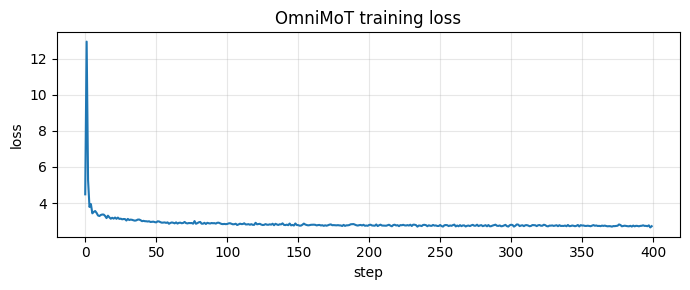


  SECTION 4 — Autoregressive world-model rollout (forward_dynamics analog)

A world model predicts the FUTURE. Here we give the trained model a partial vision
trajectory and let it roll the vision latents forward one step at a time — exactly
the loop Cosmos 3 runs for `forward_dynamics` (predict future frames) and `policy`
(predict future frames + actions). We compare the model's imagined trajectory to the
ground-truth physics (the hidden VIS_DYN map) it never saw explicitly.

Rolled out 5 future vision latents for 4 scenes.
Imagined-vs-true-physics MSE : 0.0089   (a small number = it learned the dynamics)
Example (scene 0) latent[0] over time:
   predicted : [0.18199999630451202, 0.052000001072883606, 0.843999981880188, -0.4390000104904175, 0.4350000023841858]
   true      : [0.13699999451637268, -0.004000000189989805, 0.8939999938011169, -0.6399999856948853, 0.5350000262260437]

  SECTION 5 — Real Cosmos 3 inference: valid input specs, commands, hardware table
Wrote 6 ready-to-use, 

In [1]:
rule("SECTION 5 — Real Cosmos 3 inference: valid input specs, commands, hardware table")

specs = {
    "t2i.json": {
        "model_mode": "text2image",
        "prompt": "a robot arm neatly stacking three wooden blocks on a lab bench, cinematic",
        "resolution": "480", "aspect_ratio": "16,9", "num_frames": 1, "seed": 0,
    },
    "t2v.json": {
        "model_mode": "text2video",
        "prompt": "first-person view of a warehouse AMR navigating around pallets, smooth motion",
        "resolution": "480", "aspect_ratio": "16,9", "fps": 16, "num_frames": 121, "seed": 0,
    },
    "t2vs.json": {
        "model_mode": "text2video", "enable_sound": True,
        "prompt": "rain falling on a tin roof at night, distant thunder, puddles rippling",
        "resolution": "480", "fps": 16, "num_frames": 121, "seed": 0,
    },
    "i2v.json": {
        "model_mode": "image2video",
        "prompt": "the camera slowly pushes in as steam rises from the cup",
        "vision_path": "assets/first_frame.jpg",
        "resolution": "480", "fps": 16, "num_frames": 121, "seed": 0,
    },
    "action_forward_dynamics_robot.json": {
        "model_mode": "forward_dynamics",
        "domain_name": "bridge_orig_lerobot", "view_point": "ego_view",
        "vision_path": "assets/obs.mp4", "action_path": "assets/actions.json",
        "action_chunk_size": 12, "image_size": 256, "seed": 0,
    },
    "action_policy_robot.json": {
        "model_mode": "policy",
        "domain_name": "bridge_orig_lerobot", "view_point": "ego_view",
        "vision_path": "assets/obs.mp4", "prompt": "pick up the red cube and place it in the bowl",
        "action_chunk_size": 12, "image_size": 256, "seed": 0,
    },
}
spec_dir = (Path("/content") if Path("/content").exists() else Path(".")) / "cosmos_inputs"
spec_dir.mkdir(exist_ok=True)
for name, obj in specs.items():
    (spec_dir / name).write_text(json.dumps(obj, indent=2))
print(f"Wrote {len(specs)} ready-to-use, schema-correct input specs to: {spec_dir}\n")
print("Example — text2video spec (inputs/omni/t2v.json):")
print(textwrap.indent(json.dumps(specs["t2v.json"], indent=2), "   "))

print("""
EXACT launch commands (run these where you have the hardware; do NOT expect them on Colab):

  # Single 80GB H100 — Nano only, latency preset (lowest per-sample wall time)
  python -m cosmos_framework.scripts.inference \\
      --parallelism-preset=latency \\
      -i "cosmos_inputs/t2v.json" -o outputs/nano \\
      --checkpoint-path Cosmos3-Nano --seed 0

  # Whole batch on 8x H100 — Nano, throughput preset
  torchrun --nproc-per-node=8 -m cosmos_framework.scripts.inference \\
      --parallelism-preset=throughput \\
      -i "cosmos_inputs/*.json" -o outputs/nano_batch \\
      --checkpoint-path Cosmos3-Nano --seed 0

  # Cosmos3-Super (65B) — must shard across GPUs (does NOT fit on one H100)
  torchrun --nproc-per-node=4 -m cosmos_framework.scripts.inference \\
      --parallelism-preset=throughput --dp-shard-size=4 --dp-replicate-size=1 \\
      --cp-size=1 --cfgp-size=1 \\
      -i "cosmos_inputs/t2v.json" -o outputs/super \\
      --checkpoint-path Cosmos3-Super --seed 0

  # Tight on memory? climb this ladder (from docs/faq.md):
  export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
  ... --offload-guardrail-models         # keep guardrails on CPU between calls
  ... --no-guardrails                     # (last resort; disables safety filters)
""")

print("  Model / hardware reality table")
print("  " + "-" * 82)
print(f"  {'Model':<16}{'Params':<9}{'Fits on 1x H100 80GB?':<24}{'Recommended':<18}")
print("  " + "-" * 82)
for m, pr, one, rec in [
    ("Cosmos3-Nano",  "16B", "Yes (latency preset)",   "1-8x H100"),
    ("Cosmos3-Super", "65B", "No — must shard (FSDP)",  "4-8x H100"),
]:
    print(f"  {m:<16}{pr:<9}{one:<24}{rec:<18}")
print("  " + "-" * 82)

rule("SECTION 6 — Summary")
print(textwrap.dedent(f"""
    You ran, end to end on {'a ' + gpu_name if CUDA_OK else 'CPU'}:
      1. An honest capability probe (this box cannot run the 16B+ Cosmos 3 checkpoints).
      2. A map of the real cosmos_framework package, CLI, modes and input schema.
      3. A from-scratch ~{n_params/1e6:.1f}M-param omnimodal Mixture-of-Transformers world
         model — shared cross-modal causal attention + per-modality expert FFNs, RoPE,
         RMSNorm, SwiGLU — TRAINED live (loss {hist[0]:.2f} -> {hist[-1]:.2f}).
      4. An autoregressive world-model rollout (forward_dynamics/policy), imagined-vs-true
         physics MSE = {err:.4f}.
      5. Six schema-correct Cosmos 3 input specs + the exact launch commands.

    To run the REAL models, use a machine with Ampere+ GPUs (Hopper/Blackwell recommended),
    CUDA>=12.8 and ~150GB free disk, then:
      git clone https://github.com/NVIDIA/cosmos-framework && cd cosmos-framework
      curl -LsSf https://astral.sh/uv/install.sh | sh && source $HOME/.local/bin/env
      uv sync --all-extras --group=cu130-train        # or cu128-train for CUDA 12.8
      source .venv/bin/activate && export LD_LIBRARY_PATH=
      export HF_TOKEN=...                              # accept model licenses on HF first
      python -m cosmos_framework.scripts.inference --parallelism-preset=latency \\
          -i cosmos_inputs/t2v.json -o outputs/nano --checkpoint-path Cosmos3-Nano --seed 0

    Docs:  setup → docs/setup.md · inference → docs/inference.md · training → docs/training.md
    Models: https://huggingface.co/collections/nvidia/cosmos3
"""))
print("Done. ✅  This whole tutorial ran without a single gated download or 80GB GPU.")